In [ ]:
# ============================================================
#
# IceCube IceTracks-DR2  Complete Point Source Search 
#
# ============================================================
 

In [8]:
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize_scalar
from scipy.stats import gaussian_kde, chi2
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
 
DATA_DIR = Path("/kaggle/input/datasets/binishbatool")
IRFS_FOLDER = "irfsss"
 
ALL_FIGURES = []  # (name, fig) pairs, collected for the combined PDF report
 
 
def save_and_track(fig, name, dpi=120):
    """Save a figure as PNG + vector PDF, track it for the combined report."""
    fig.savefig(f"{name}.png", dpi=dpi, bbox_inches="tight")
    fig.savefig(f"{name}.pdf", bbox_inches="tight")
    ALL_FIGURES.append((name, fig))
    plt.show()
 
 
def load_ic_tab(path):
    header = None
    rows = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#"):
                header = line.lstrip("#").split()
                continue
            line = line.strip('"')
            parts = line.split()
            rows.append([float(x) for x in parts])
    if header is None:
        raise ValueError(f"No header line found in {path}")
    return pd.DataFrame(rows, columns=header)
 
 
# ------------------------------------------------------------
# Cell: Load events, effective area, smearing matrix
# ------------------------------------------------------------
event_files = sorted((DATA_DIR / "events").glob("IC86_*_exp.tab"))
events_list = []
for f in event_files:
    df = load_ic_tab(f)
    df["season"] = f.stem
    events_list.append(df)
events = pd.concat(events_list, ignore_index=True)
events["AngErr[deg]"] = events["AngErr[deg]"].clip(lower=0.2)
print(f"Loaded {len(events)} events from {len(event_files)} seasons")
 
aeff = load_ic_tab(DATA_DIR / IRFS_FOLDER / "IC86_effectiveArea.tab")
smearing = load_ic_tab(DATA_DIR / IRFS_FOLDER / "IC86_smearing.csv")
print(f"Loaded effective area ({len(aeff)} bins) and smearing matrix ({len(smearing)} bins)")
 
ra_all = np.radians(events["RA[deg]"].values)
dec_all = np.radians(events["Dec[deg]"].values)
sigma_all = np.radians(events["AngErr[deg]"].values)
logE_all = events["log10(E/GeV)"].values
N_total = len(events)

print("cell ended")


Loaded 621887 events from 5 seasons
Loaded effective area (2000 bins) and smearing matrix (3360000 bins)
cell ended


In [12]:

# ------------------------------------------------------------
# Cell: Source position
# ------------------------------------------------------------
SOURCE_NAME = "TXS 0506+056"
SOURCE_RA_DEG = 77.3582
SOURCE_DEC_DEG = 5.6931
src_ra = np.radians(SOURCE_RA_DEG)
src_dec = np.radians(SOURCE_DEC_DEG)
print(f"\nTarget source: {SOURCE_NAME} (RA={SOURCE_RA_DEG}, Dec={SOURCE_DEC_DEG}) "
      f"-- fixed, pre-specified analysis target, not derived from the data.")
 
 
# ------------------------------------------------------------
# Cell: Spatial PDFs
# ------------------------------------------------------------
def angular_distance(ra1, dec1, ra2, dec2):
    cos_psi = (np.sin(dec1) * np.sin(dec2) +
               np.cos(dec1) * np.cos(dec2) * np.cos(ra1 - ra2))
    cos_psi = np.clip(cos_psi, -1.0, 1.0)
    return np.arccos(cos_psi)
 
sin_dec_all = np.sin(dec_all)
N_BINS = 50
hist_counts, bin_edges = np.histogram(sin_dec_all, bins=N_BINS, range=(-1, 1), density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
 
def g_sindec(x):
    return np.interp(x, bin_centers, hist_counts)
 
def B_spatial(dec_query):
    g = np.clip(g_sindec(np.sin(dec_query)), 1e-8, None)
    return g / (2 * np.pi)
 
def S_spatial(ra_query, dec_query, sigma_query, src_ra, src_dec):
    psi = angular_distance(ra_query, dec_query, src_ra, src_dec)
    return (1.0 / (2 * np.pi * sigma_query**2)) * np.exp(-psi**2 / (2 * sigma_query**2))
 
S_sp = S_spatial(ra_all, dec_all, sigma_all, src_ra, src_dec)
B_sp = B_spatial(dec_all)
 
 
# ------------------------------------------------------------
# Cell: Find declination bins
# ------------------------------------------------------------
def find_dec_bin(dec_deg, table):
    mask = (table["Dec_nu_min[deg]"] <= dec_deg) & (table["Dec_nu_max[deg]"] > dec_deg)
    return table[mask]["Dec_nu_min[deg]"].iloc[0], table[mask]["Dec_nu_max[deg]"].iloc[0]
 
src_dec_min, src_dec_max = find_dec_bin(SOURCE_DEC_DEG, aeff)
print(f"\nSource Dec={SOURCE_DEC_DEG} falls in aeff's Dec_nu bin [{src_dec_min}, {src_dec_max}]")
 
src_dec_min_smear, src_dec_max_smear = find_dec_bin(SOURCE_DEC_DEG, smearing)
print(f"(smearing table uses its own Dec_nu bin [{src_dec_min_smear}, {src_dec_max_smear}])")
 
smearing_local = smearing[(smearing["Dec_nu_min[deg]"] == src_dec_min_smear) &
                            (smearing["Dec_nu_max[deg]"] == src_dec_max_smear)].copy()
 
 
# ------------------------------------------------------------
# Cell: Background sample and raw histogram
# ------------------------------------------------------------
E_reco_edges = np.unique(np.concatenate([smearing_local["log10(E/GeV)_min"].values,
                                          smearing_local["log10(E/GeV)_max"].values]))
E_reco_edges.sort()
bin_centers_E_reco = 0.5 * (E_reco_edges[:-1] + E_reco_edges[1:])
 
dec_band_mask = (events["Dec[deg]"] >= src_dec_min) & (events["Dec[deg]"] < src_dec_max)
bkg_logE_sample = logE_all[dec_band_mask.values]
print(f"\nBackground energy sample: {len(bkg_logE_sample)} events in Dec band [{src_dec_min}, {src_dec_max}]")
 
bkg_hist_density, _ = np.histogram(bkg_logE_sample, bins=E_reco_edges, density=True)
bkg_hist_counts, _ = np.histogram(bkg_logE_sample, bins=E_reco_edges)
print(f"[raw histogram] Bins with < 20 events: {(bkg_hist_counts < 20).sum()} / {len(bkg_hist_counts)}")
 


Target source: TXS 0506+056 (RA=77.3582, Dec=5.6931) -- fixed, pre-specified analysis target, not derived from the data.

Source Dec=5.6931 falls in aeff's Dec_nu bin [4.59, 6.89]
(smearing table uses its own Dec_nu bin [0.0, 5.73917])

Background energy sample: 23878 events in Dec band [4.59, 6.89]
[raw histogram] Bins with < 20 events: 230 / 293



------------------------------------------------------------
DIAGNOSTIC: KDE bandwidth selection (well-sampled core region)
------------------------------------------------------------
  scott (1.0x): factor=0.1332, peak ratio=0.853
  0.5x scott: factor=0.0666, peak ratio=0.880
  0.25x scott: factor=0.0333, peak ratio=0.891
  0.1x scott: factor=0.0133, peak ratio=0.750
Selected KDE bandwidth for core region: scott (1.0x)


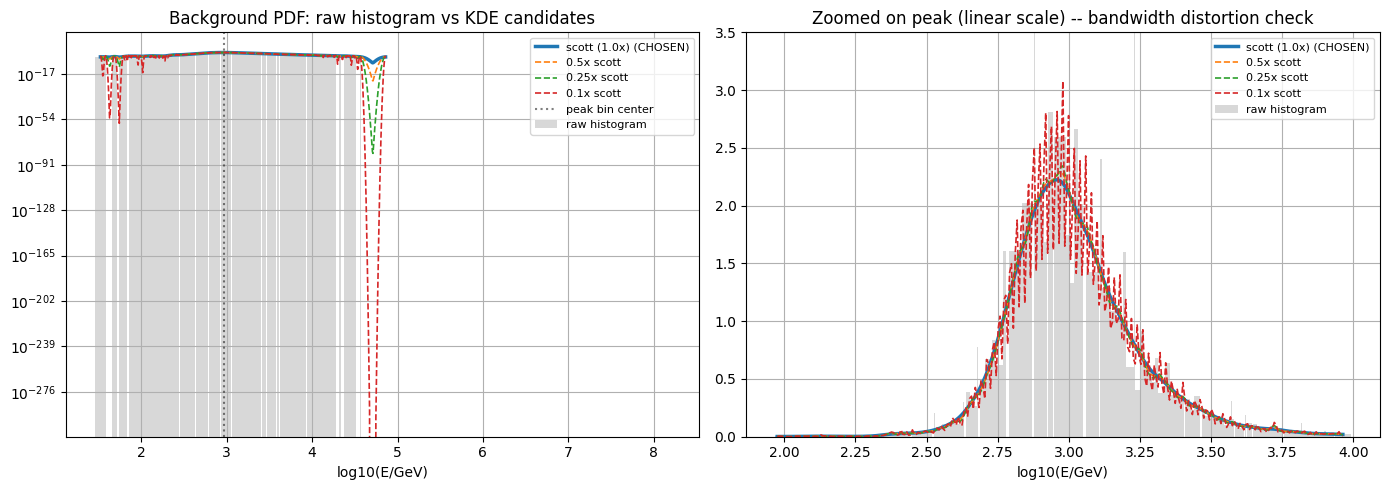

cell ended


In [13]:

# ------------------------------------------------------------
# Cell: Bandwidth diagnosis
# ------------------------------------------------------------
print("\n" + "-"*60)
print("DIAGNOSTIC: KDE bandwidth selection (well-sampled core region)")
print("-"*60)
 
kde_scott = gaussian_kde(bkg_logE_sample, bw_method="scott")
scott_factor = kde_scott.factor
 
peak_bin_idx = np.argmax(bkg_hist_counts)
peak_center = bin_centers_E_reco[peak_bin_idx]
peak_raw_density = bkg_hist_density[peak_bin_idx]
 
candidate_factors = {
    "scott (1.0x)": scott_factor, "0.5x scott": scott_factor * 0.5,
    "0.25x scott": scott_factor * 0.25, "0.1x scott": scott_factor * 0.1,
}
grid_lo, grid_hi = bkg_logE_sample.min(), bkg_logE_sample.max()
kde_grid = np.linspace(grid_lo, grid_hi, 500)
 
candidate_densities = {}
chosen_label, chosen_factor = None, None
for label, factor in candidate_factors.items():
    kde = gaussian_kde(bkg_logE_sample, bw_method=factor)
    density = kde(kde_grid)
    candidate_densities[label] = density
    ratio = np.interp(peak_center, kde_grid, density) / peak_raw_density
    print(f"  {label}: factor={factor:.4f}, peak ratio={ratio:.3f}")
    if chosen_label is None and 0.5 <= ratio <= 2.0:
        chosen_label, chosen_factor = label, factor
if chosen_label is None:
    chosen_label, chosen_factor = "0.1x scott", scott_factor * 0.1
print(f"Selected KDE bandwidth for core region: {chosen_label}")
 
bkg_kde = gaussian_kde(bkg_logE_sample, bw_method=chosen_factor)
bkg_kde_density_grid = bkg_kde(kde_grid)
 
# --- Figure 01: bandwidth candidate comparison ---
fig01, ax01 = plt.subplots(1, 2, figsize=(14, 5))
ax01[0].bar(bin_centers_E_reco, bkg_hist_density, width=np.diff(E_reco_edges),
            alpha=0.3, color='gray', label='raw histogram')
for label, density in candidate_densities.items():
    style = '-' if label == chosen_label else '--'
    lw = 2.5 if label == chosen_label else 1.2
    ax01[0].plot(kde_grid, density, style, linewidth=lw,
                 label=f"{label}{' (CHOSEN)' if label == chosen_label else ''}")
ax01[0].axvline(peak_center, color='k', linestyle=':', alpha=0.5, label='peak bin center')
ax01[0].set_yscale('log')
ax01[0].set_title('Background PDF: raw histogram vs KDE candidates')
ax01[0].set_xlabel('log10(E/GeV)')
ax01[0].legend(fontsize=8)
ax01[0].grid(True)
 
zoom_mask = (bin_centers_E_reco > peak_center - 1) & (bin_centers_E_reco < peak_center + 1)
ax01[1].bar(bin_centers_E_reco[zoom_mask], bkg_hist_density[zoom_mask],
            width=np.diff(E_reco_edges)[zoom_mask], alpha=0.3, color='gray', label='raw histogram')
zoom_grid_mask = (kde_grid > peak_center - 1) & (kde_grid < peak_center + 1)
for label, density in candidate_densities.items():
    style = '-' if label == chosen_label else '--'
    lw = 2.5 if label == chosen_label else 1.2
    ax01[1].plot(kde_grid[zoom_grid_mask], density[zoom_grid_mask], style, linewidth=lw,
                 label=f"{label}{' (CHOSEN)' if label == chosen_label else ''}")
ax01[1].set_title('Zoomed on peak (linear scale) -- bandwidth distortion check')
ax01[1].set_xlabel('log10(E/GeV)')
ax01[1].set_ylim(0,3.5)
ax01[1].legend(fontsize=8)
ax01[1].grid(True)
plt.tight_layout()
save_and_track(fig01, "icecube_v6_01_bandwidth_selection")
print("cell ended")
 


------------------------------------------------------------
DIAGNOSTIC: power-law extrapolation for sparse regions
------------------------------------------------------------
Trusted range (>= 20 events/bin): logE in [2.39, 3.96] (63 / 293 bins)
Fitted power-law: log10(density) = -0.4747 * logE + 1.1339 (spectral slope -0.47, falling)


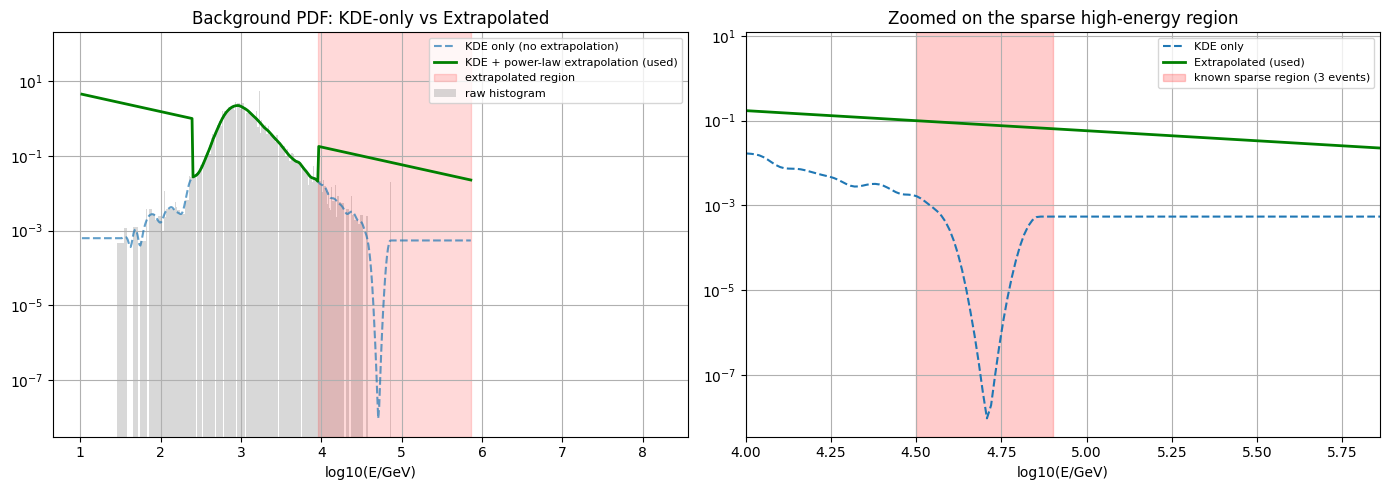

cell ended


In [14]:

# ------------------------------------------------------------
# Cell: Power-law extrapolation for sparse regions
# ------------------------------------------------------------
print("\n" + "-"*60)
print("DIAGNOSTIC: power-law extrapolation for sparse regions")
print("-"*60)
 
MIN_TRUSTED_COUNT = 20
trusted_mask = bkg_hist_counts >= MIN_TRUSTED_COUNT
trusted_logE = bin_centers_E_reco[trusted_mask]
trusted_density = bkg_hist_density[trusted_mask]
trusted_logE_sorted_idx = np.argsort(trusted_logE)
trusted_logE = trusted_logE[trusted_logE_sorted_idx]
trusted_density = trusted_density[trusted_logE_sorted_idx]
 
print(f"Trusted range (>= {MIN_TRUSTED_COUNT} events/bin): "
      f"logE in [{trusted_logE.min():.2f}, {trusted_logE.max():.2f}] "
      f"({trusted_mask.sum()} / {len(bkg_hist_counts)} bins)")
 
log_density_trusted = np.log10(np.clip(trusted_density, 1e-30, None))
slope, intercept = np.polyfit(trusted_logE, log_density_trusted, deg=1)
print(f"Fitted power-law: log10(density) = {slope:.4f} * logE + {intercept:.4f} "
      f"(spectral slope {slope:.2f}, {'falling' if slope < 0 else 'RISING -- check this!'})")
 
min_trusted_logE = trusted_logE.min()
max_trusted_logE = trusted_logE.max()
 
def B_energy(logE_query):
    logE_query = np.atleast_1d(np.asarray(logE_query, dtype=float))
    val = np.interp(logE_query, kde_grid, bkg_kde_density_grid,
                     left=bkg_kde_density_grid[0], right=bkg_kde_density_grid[-1])
    extrap_mask = (logE_query > max_trusted_logE) | (logE_query < min_trusted_logE)
    if extrap_mask.any():
        val = val.copy()
        val[extrap_mask] = 10 ** (slope * logE_query[extrap_mask] + intercept)
    return np.clip(val, 1e-10, None)
 
# --- Figure 02: KDE-only vs KDE+extrapolation comparison ---
fig02, ax02 = plt.subplots(1, 2, figsize=(14, 5))
plot_grid = np.linspace(bkg_logE_sample.min() - 0.5, bkg_logE_sample.max() + 1.0, 400)
kde_only = np.interp(plot_grid, kde_grid, bkg_kde_density_grid,
                      left=bkg_kde_density_grid[0], right=bkg_kde_density_grid[-1])
final_bg = B_energy(plot_grid)
 
ax02[0].bar(bin_centers_E_reco, bkg_hist_density, width=np.diff(E_reco_edges),
            alpha=0.3, color='gray', label='raw histogram')
ax02[0].plot(plot_grid, kde_only, '--', label='KDE only (no extrapolation)', alpha=0.7)
ax02[0].plot(plot_grid, final_bg, '-', linewidth=2, color='green',
             label='KDE + power-law extrapolation (used)')
ax02[0].axvspan(max_trusted_logE, plot_grid.max(), alpha=0.15, color='red',
                label='extrapolated region')
ax02[0].set_yscale('log')
ax02[0].set_title('Background PDF: KDE-only vs Extrapolated')
ax02[0].set_xlabel('log10(E/GeV)')
ax02[0].legend(fontsize=8)
ax02[0].grid(True)
 
ax02[1].plot(plot_grid, kde_only, '--', label='KDE only')
ax02[1].plot(plot_grid, final_bg, '-', linewidth=2, color='green', label='Extrapolated (used)')
ax02[1].axvspan(4.5, 4.9, alpha=0.2, color='red', label='known sparse region (3 events)')
ax02[1].set_yscale('log')
ax02[1].set_xlim(4.0, plot_grid.max())
ax02[1].set_title('Zoomed on the sparse high-energy region')
ax02[1].set_xlabel('log10(E/GeV)')
ax02[1].legend(fontsize=8)
ax02[1].grid(True)
plt.tight_layout()
save_and_track(fig02, "icecube_v6_02_background_extrapolation")
print("cell ended")
 


Matched 112000 / 112000 smearing rows to a nonzero A_Eff bin


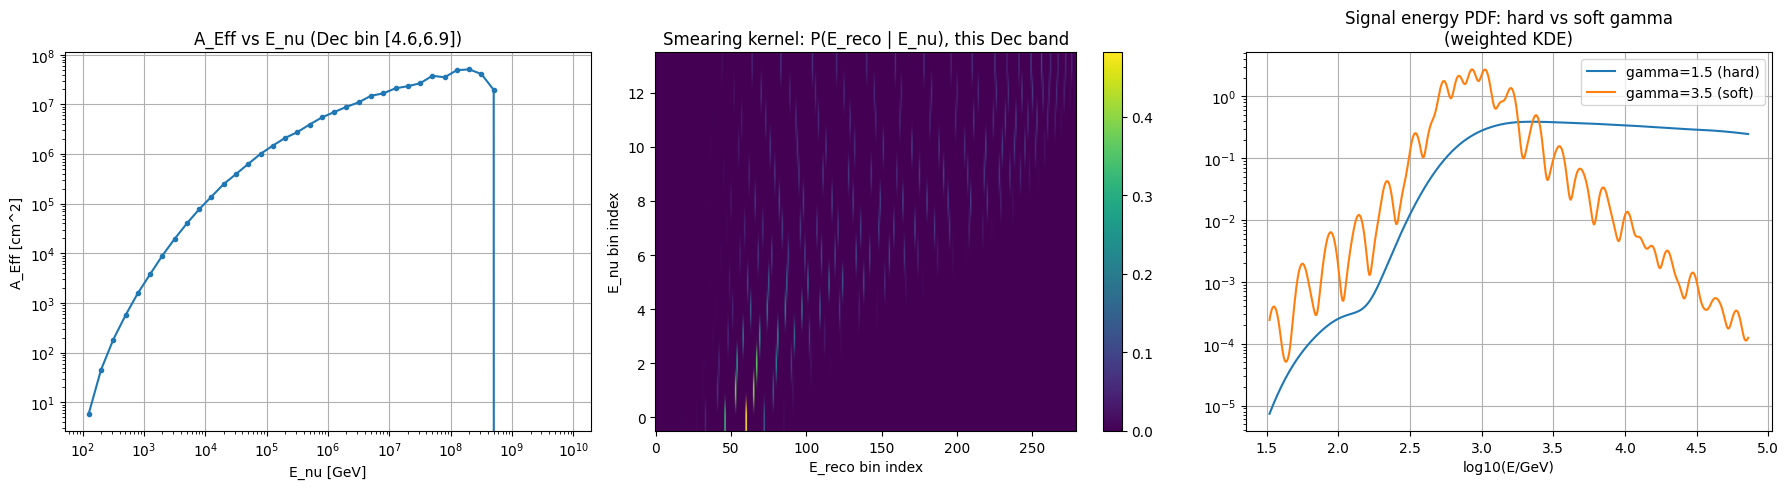

cell ended


In [15]:
 
# ------------------------------------------------------------
# Cell: Signal PDF via weighted KDE
# ------------------------------------------------------------
aeff_local = aeff[(aeff["Dec_nu_min[deg]"] == src_dec_min) &
                   (aeff["Dec_nu_max[deg]"] == src_dec_max)].copy()
aeff_local["E_nu_center"] = np.sqrt(10**aeff_local["log10(E_nu/GeV)_min"] *
                                     10**aeff_local["log10(E_nu/GeV)_max"])
 
smearing_local["E_nu_center"] = np.sqrt(10**smearing_local["log10(E_nu/GeV)_min"] *
                                          10**smearing_local["log10(E_nu/GeV)_max"])
smearing_local["dE_nu"] = (10**smearing_local["log10(E_nu/GeV)_max"] -
                            10**smearing_local["log10(E_nu/GeV)_min"])
smearing_local["E_reco_center"] = 0.5 * (smearing_local["log10(E/GeV)_min"] +
                                          smearing_local["log10(E/GeV)_max"])
smearing_local["PSF_center"] = 0.5 * (smearing_local["PSF_min[deg]"] +
                                       smearing_local["PSF_max[deg]"])
 
def lookup_aeff_by_containment(e_nu_centers, aeff_table):
    log_e = np.log10(e_nu_centers)
    aeff_mins = aeff_table["log10(E_nu/GeV)_min"].values
    aeff_maxs = aeff_table["log10(E_nu/GeV)_max"].values
    aeff_vals = aeff_table["A_Eff[cm^2]"].values
    result = np.zeros(len(log_e))
    for i, le in enumerate(log_e):
        mask = (aeff_mins <= le) & (aeff_maxs > le)
        if mask.any():
            result[i] = aeff_vals[mask][0]
    return result
 
smearing_local["A_Eff[cm^2]"] = lookup_aeff_by_containment(
    smearing_local["E_nu_center"].values, aeff_local
)
n_matched = (smearing_local["A_Eff[cm^2]"] > 0).sum()
print(f"\nMatched {n_matched} / {len(smearing_local)} smearing rows to a nonzero A_Eff bin")
 
merged = smearing_local
 
def build_signal_energy_kde(gamma):
    flux_weight = merged["E_nu_center"] ** (-gamma)
    nu_weight = flux_weight * merged["dE_nu"] * merged["A_Eff[cm^2]"]
    weights = (nu_weight * merged["Fractional_Counts"]).values
    points = merged["E_reco_center"].values
 
    total_weight = weights.sum()
    if total_weight <= 0:
        return lambda logE_query: B_energy(logE_query)
 
    nonzero = weights > 0
    points_nz, weights_nz = points[nonzero], weights[nonzero]
    if len(points_nz) < 2:
        return lambda logE_query: B_energy(logE_query)
 
    sig_kde = gaussian_kde(points_nz, bw_method=chosen_factor, weights=weights_nz)
    sig_density_grid = sig_kde(kde_grid)
 
    def lookup(logE_query):
        val = np.interp(logE_query, kde_grid, sig_density_grid,
                         left=sig_density_grid[0] * 0.1, right=sig_density_grid[-1] * 0.1)
        return np.clip(val, 1e-8, None)
    return lookup
 
# --- Figure 03: ingredient diagnostics (A_Eff, smearing kernel, hard/soft gamma preview) ---
fig03, ax03 = plt.subplots(1, 3, figsize=(18, 5))
 
ax03[0].plot(aeff_local["E_nu_center"], aeff_local["A_Eff[cm^2]"], marker='o', markersize=3)
ax03[0].set_xscale("log")
ax03[0].set_yscale("log")
ax03[0].set_title(f"A_Eff vs E_nu (Dec bin [{src_dec_min:.1f},{src_dec_max:.1f}])")
ax03[0].set_xlabel("E_nu [GeV]")
ax03[0].set_ylabel("A_Eff [cm^2]")
ax03[0].grid(True)
 
kernel = smearing_local.groupby(
    ["log10(E_nu/GeV)_min", "log10(E/GeV)_min"]
)["Fractional_Counts"].sum().unstack(fill_value=0)
im03 = ax03[1].imshow(kernel.values, origin="lower", aspect="auto", cmap="viridis")
ax03[1].set_title("Smearing kernel: P(E_reco | E_nu), this Dec band")
ax03[1].set_xlabel("E_reco bin index")
ax03[1].set_ylabel("E_nu bin index")
plt.colorbar(im03, ax=ax03[1])
 
sig_fn_hard = build_signal_energy_kde(1.5)
sig_fn_soft = build_signal_energy_kde(3.5)
ax03[2].plot(kde_grid, sig_fn_hard(kde_grid), label='gamma=1.5 (hard)')
ax03[2].plot(kde_grid, sig_fn_soft(kde_grid), label='gamma=3.5 (soft)')
ax03[2].set_yscale('log')
ax03[2].set_title('Signal energy PDF: hard vs soft gamma\n(weighted KDE)')
ax03[2].set_xlabel('log10(E/GeV)')
ax03[2].legend()
ax03[2].grid(True)
plt.tight_layout()
save_and_track(fig03, "icecube_v6_03_ingredient_diagnostics")
print("cell ended")
 


Precomputing signal/background energy terms for 11 gamma values...


Precomputing energy PDFs: 100%|██████████| 11/11 [00:02<00:00,  3.89it/s]



Profiling over gamma at the real source position...


Gamma scan:   9%|▉         | 1/11 [00:00<00:04,  2.12it/s]

  gamma=1.50: TS=0.7551, n_s=1.861


...

  gamma=3.50: TS=-0.0000, n_s=0.000


Gamma scan:  91%|█████████ | 10/11 [00:04<00:00,  2.00it/s]

  gamma=3.75: TS=-0.0000, n_s=0.000


Gamma scan: 100%|██████████| 11/11 [00:05<00:00,  2.12it/s]

  gamma=4.00: TS=-0.0000, n_s=0.000

Best fit: TS = 5.030, gamma = 2.50, n_s = 11.98


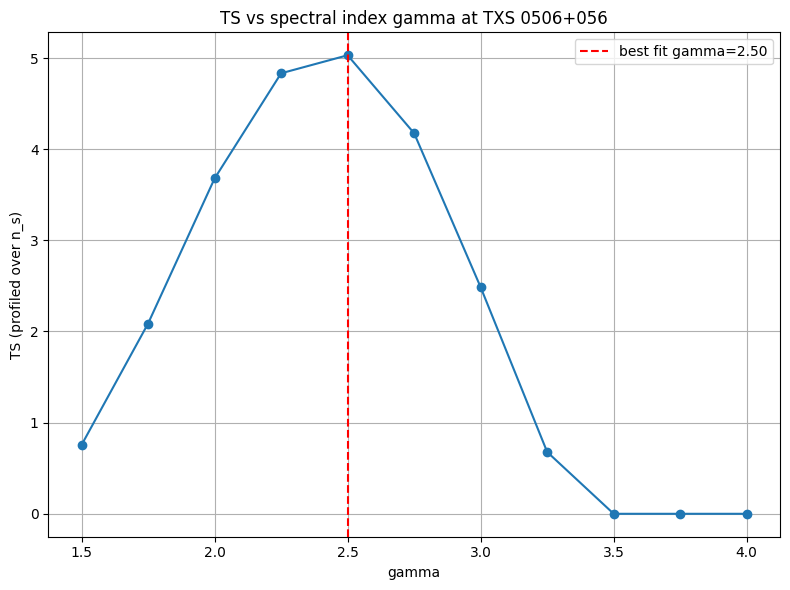

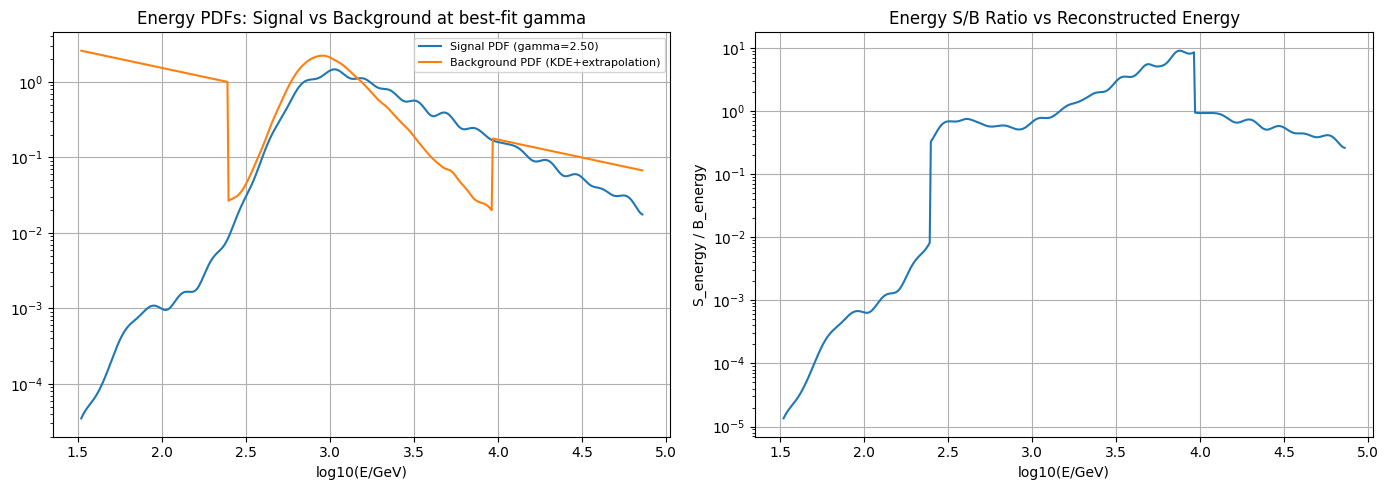

cell ended


In [17]:

# ------------------------------------------------------------
# Cell: Precompute energy terms per gamma, fit
# ------------------------------------------------------------
GAMMA_GRID = np.arange(1.5, 4.01, 0.25)
print(f"\nPrecomputing signal/background energy terms for {len(GAMMA_GRID)} gamma values...")
 
B_en_all = B_energy(logE_all)
S_en_all_by_gamma = {}
for gamma in tqdm(GAMMA_GRID, desc="Precomputing energy PDFs"):
    S_energy_fn = build_signal_energy_kde(gamma)
    S_en_all_by_gamma[gamma] = S_energy_fn(logE_all)
 
def compute_TS_energy_fast(ra_src, dec_src, gamma, ra_evt, dec_evt, sigma_evt, N,
                            return_top_event=False):
    S_sp_local = S_spatial(ra_evt, dec_evt, sigma_evt, ra_src, dec_src)
    B_sp_local = B_spatial(dec_evt)
    S_en = S_en_all_by_gamma[gamma]
    B_en = B_en_all
    S = S_sp_local * S_en
    B = B_sp_local * B_en
    ratio = S / B
 
    def neg_TS(n_s):
        x = 1.0 + (n_s / N) * (ratio - 1.0)
        x = np.clip(x, 1e-12, None)
        return -2.0 * np.sum(np.log(x))
 
    result = minimize_scalar(neg_TS, bounds=(0, N), method="bounded")
    TS, n_s = -result.fun, result.x
    if return_top_event:
        return TS, n_s, np.argmax(ratio)
    return TS, n_s
 
 
print(f"\nProfiling over gamma at the real source position...")
ts_vs_gamma, ns_vs_gamma = [], []
for gamma in tqdm(GAMMA_GRID, desc="Gamma scan"):
    ts, ns = compute_TS_energy_fast(src_ra, src_dec, gamma, ra_all, dec_all, sigma_all, N_total)
    ts_vs_gamma.append(ts)
    ns_vs_gamma.append(ns)
    print(f"  gamma={gamma:.2f}: TS={ts:.4f}, n_s={ns:.3f}")
 
ts_vs_gamma = np.array(ts_vs_gamma)
ns_vs_gamma = np.array(ns_vs_gamma)
best_idx = np.argmax(ts_vs_gamma)
TS_obs = ts_vs_gamma[best_idx]
gamma_obs = GAMMA_GRID[best_idx]
n_s_obs = ns_vs_gamma[best_idx]
print(f"\nBest fit: TS = {TS_obs:.3f}, gamma = {gamma_obs:.2f}, n_s = {n_s_obs:.2f}")
 
# --- Figure 04: TS vs gamma scan ---
fig04, ax04 = plt.subplots(figsize=(8, 6))
ax04.plot(GAMMA_GRID, ts_vs_gamma, marker='o')
ax04.axvline(gamma_obs, color='r', linestyle='--', label=f'best fit gamma={gamma_obs:.2f}')
ax04.set_title(f'TS vs spectral index gamma at {SOURCE_NAME}')
ax04.set_xlabel('gamma')
ax04.set_ylabel('TS (profiled over n_s)')
ax04.legend()
ax04.grid(True)
plt.tight_layout()
save_and_track(fig04, "icecube_v6_04_TS_vs_gamma")
 
# --- Figure 05: signal vs background energy PDF at best-fit gamma + S/B ratio ---
sig_fn_best = build_signal_energy_kde(gamma_obs)
best_sig_curve = sig_fn_best(kde_grid)
bg_curve_full = B_energy(kde_grid)
 
fig05, ax05 = plt.subplots(1, 2, figsize=(14, 5))
ax05[0].plot(kde_grid, best_sig_curve, label=f'Signal PDF (gamma={gamma_obs:.2f})')
ax05[0].plot(kde_grid, bg_curve_full, label='Background PDF (KDE+extrapolation)')
ax05[0].set_yscale('log')
ax05[0].set_title('Energy PDFs: Signal vs Background at best-fit gamma')
ax05[0].set_xlabel('log10(E/GeV)')
ax05[0].legend(fontsize=8)
ax05[0].grid(True)
 
ax05[1].plot(kde_grid, np.clip(best_sig_curve, 1e-10, None) / np.clip(bg_curve_full, 1e-10, None))
ax05[1].set_yscale('log')
ax05[1].set_title('Energy S/B Ratio vs Reconstructed Energy')
ax05[1].set_xlabel('log10(E/GeV)')
ax05[1].set_ylabel('S_energy / B_energy')
ax05[1].grid(True)
plt.tight_layout()
save_and_track(fig05, "icecube_v6_05_signal_vs_background_energy")
print("cell ended")
 

In [19]:
 
# ------------------------------------------------------------
# Cell: Background trials with sparse-region audit tracking
# ------------------------------------------------------------
N_TRIALS = 500
np.random.seed(42)
trial_ras = np.random.uniform(0, 2 * np.pi, N_TRIALS)
 
TS_trials = np.zeros(N_TRIALS)
trial_top_event_logE = np.zeros(N_TRIALS)
 
for i, trial_ra in enumerate(tqdm(trial_ras, desc="Background trials")):
    best_ts_this_trial, best_top_idx = -np.inf, None
    for gamma in GAMMA_GRID:
        ts, ns, top_idx = compute_TS_energy_fast(
            trial_ra, src_dec, gamma, ra_all, dec_all, sigma_all, N_total, return_top_event=True
        )
        if ts > best_ts_this_trial:
            best_ts_this_trial, best_top_idx = ts, top_idx
    TS_trials[i] = best_ts_this_trial
    trial_top_event_logE[i] = logE_all[best_top_idx]
 
p_value = np.mean(TS_trials >= TS_obs)
print(f"\nEmpirical p-value: {p_value:.4f} (from {N_TRIALS} trials)")
 
sparse_region_mask = (trial_top_event_logE > 4.5) & (trial_top_event_logE < 4.9)
n_sparse_driven = sparse_region_mask.sum()
print(f"\nAUDIT: {n_sparse_driven} / {N_TRIALS} trials driven by the formerly-problematic sparse region")
print("ccell ended")

Background trials: 100%|██████████| 500/500 [48:54<00:00,  5.87s/it]


Empirical p-value: 0.0080 (from 500 trials)

AUDIT: 0 / 500 trials driven by the formerly-problematic sparse region
ccell ended



STAGE 2 v6 CORE RESULT
Source: TXS 0506+056
Observed TS: 5.030, gamma=2.50, n_s=11.98
Empirical p-value: 0.0080 (from 500 trials)


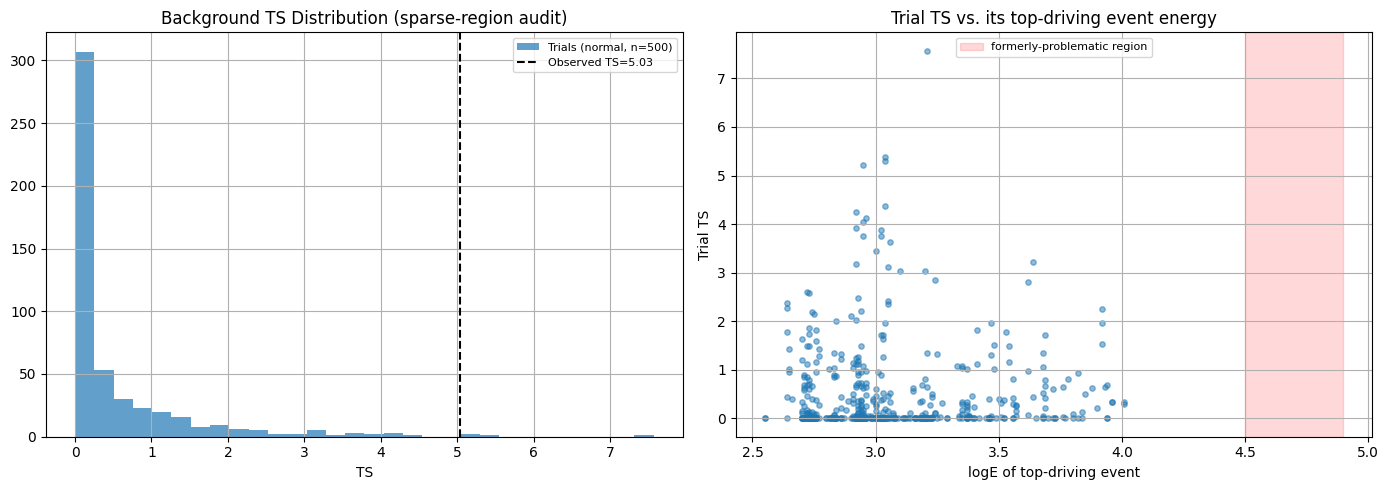

In [20]:

print("\n" + "="*50)
print("STAGE 2 v6 CORE RESULT")
print("="*50)
print(f"Source: {SOURCE_NAME}")
print(f"Observed TS: {TS_obs:.3f}, gamma={gamma_obs:.2f}, n_s={n_s_obs:.2f}")
print(f"Empirical p-value: {p_value:.4f} (from {N_TRIALS} trials)")
 
# --- Figure 06: background trials distribution + audit scatter ---
fig06, ax06 = plt.subplots(1, 2, figsize=(14, 5))
ax06[0].hist(TS_trials[~sparse_region_mask], bins=30, alpha=0.7,
             label=f'Trials (normal, n={(~sparse_region_mask).sum()})')
if n_sparse_driven > 0:
    ax06[0].hist(TS_trials[sparse_region_mask], bins=30, alpha=0.7, color='red',
                 label=f'Trials driven by sparse region (n={n_sparse_driven})')
ax06[0].axvline(TS_obs, color='k', linestyle='--', label=f'Observed TS={TS_obs:.2f}')
ax06[0].set_title('Background TS Distribution (sparse-region audit)')
ax06[0].set_xlabel('TS')
ax06[0].legend(fontsize=8)
ax06[0].grid(True)
 
ax06[1].scatter(trial_top_event_logE, TS_trials, alpha=0.5, s=15)
ax06[1].axvspan(4.5, 4.9, alpha=0.15, color='red', label='formerly-problematic region')
ax06[1].set_title('Trial TS vs. its top-driving event energy')
ax06[1].set_xlabel('logE of top-driving event')
ax06[1].set_ylabel('Trial TS')
ax06[1].legend(fontsize=8)
ax06[1].grid(True)
plt.tight_layout()
save_and_track(fig06, "icecube_v6_06_trials_audit")


GENERATING ICECUBE-STYLE DIAGNOSTIC PLOTS


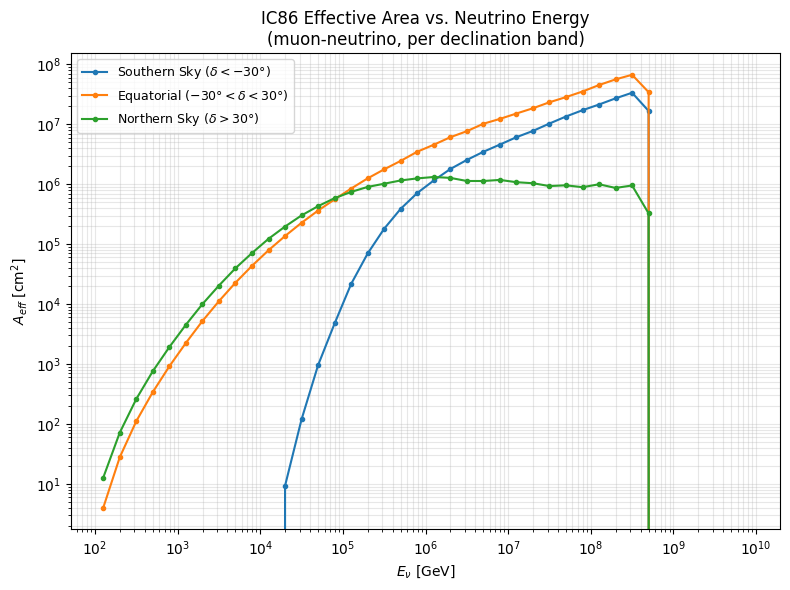

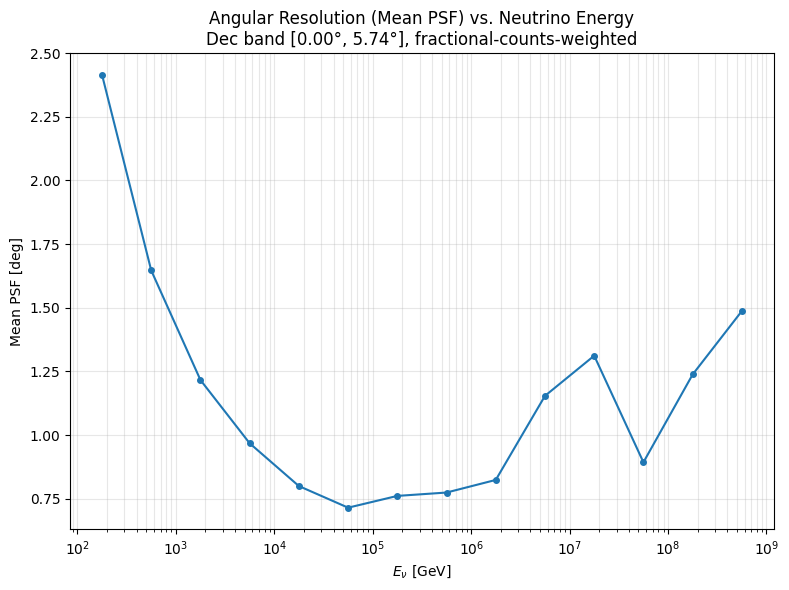

Note: 'mean PSF' here is a Fractional_Counts-weighted average per true-energy bin, not a formal median angular resolution.


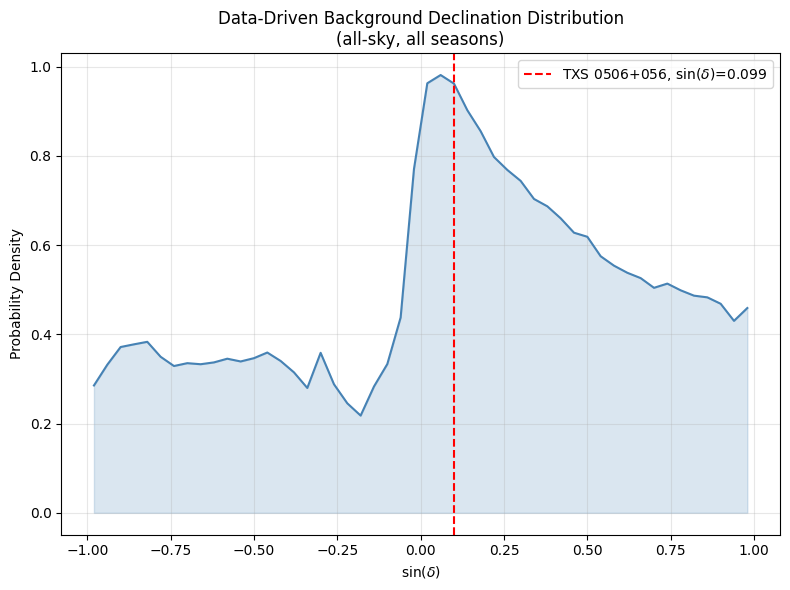

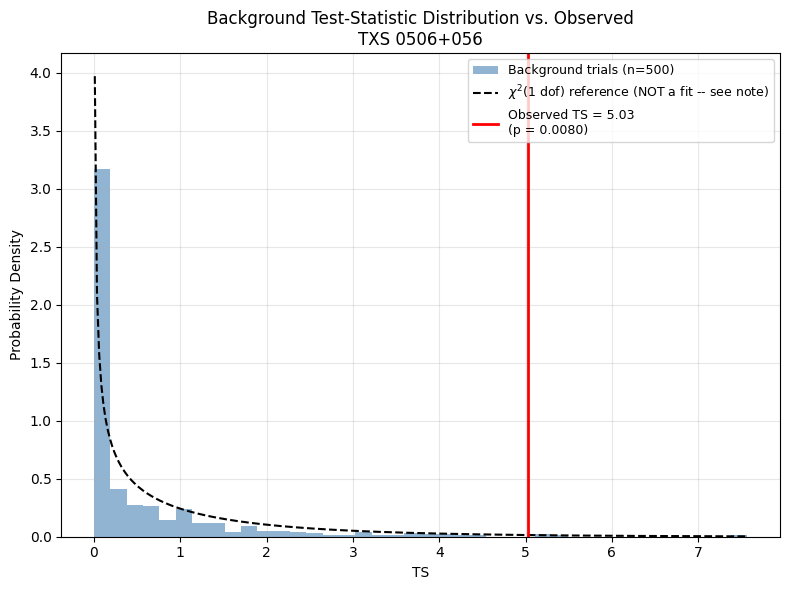

Note: chi2(1 dof) shown for visual reference only. With n_s bounded >= 0, the true asymptotic null distribution is a boundary-constrained mixture (Chernoff's theorem), not a naive chi2(ndof) -- this is why significance here is derived from trials, not an asymptotic formula.

Running 2D TS skymap scan around the source (this takes a few minutes)...


Skymap scan (Dec rows): 100%|██████████| 15/15 [22:20<00:00, 89.34s/it]


Skymap scan complete. TS at grid center: 5.030 (should be close to observed TS=5.030)


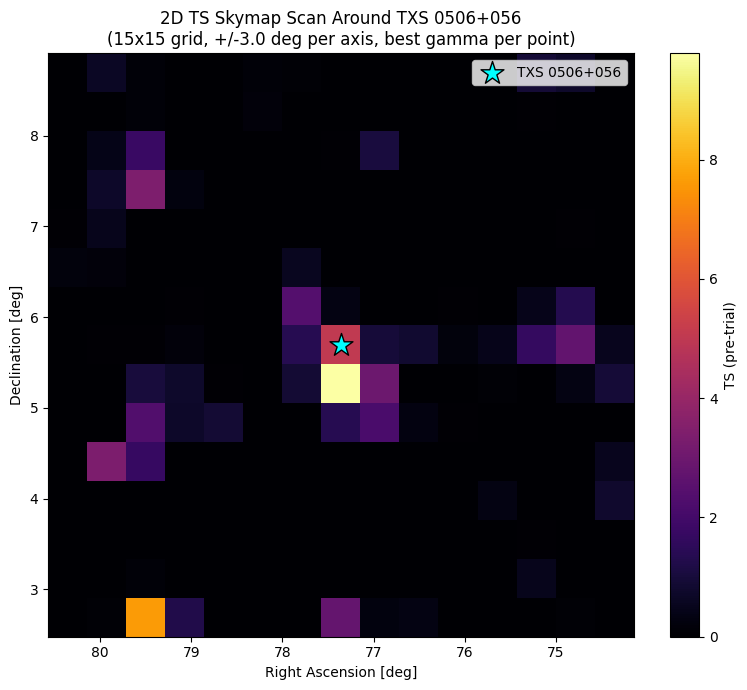

In [21]:

# ============================================================
# IceCube-collaboration-style diagnostic plots (from v5)
# ============================================================
print("\n" + "="*50)
print("GENERATING ICECUBE-STYLE DIAGNOSTIC PLOTS")
print("="*50)
 
# --- Figure 07: effective area by declination band ---
dec_bands = [(-90, -30, "Southern Sky ($\\delta < -30°$)"),
             (-30, 30, "Equatorial ($-30° < \\delta < 30°$)"),
             (30, 90, "Northern Sky ($\\delta > 30°$)")]
 
fig07, ax07 = plt.subplots(figsize=(8, 6))
for dec_lo, dec_hi, label in dec_bands:
    mask = (aeff["Dec_nu_min[deg]"] >= dec_lo) & (aeff["Dec_nu_max[deg]"] <= dec_hi)
    sub = aeff[mask].copy()
    sub["E_nu_center"] = np.sqrt(10**sub["log10(E_nu/GeV)_min"] * 10**sub["log10(E_nu/GeV)_max"])
    grouped = sub.groupby("E_nu_center")["A_Eff[cm^2]"].mean().sort_index()
    ax07.plot(grouped.index, grouped.values, marker='o', markersize=3, label=label)
ax07.set_xscale("log")
ax07.set_yscale("log")
ax07.set_xlabel(r"$E_\nu$ [GeV]")
ax07.set_ylabel(r"$A_{eff}$ [cm$^2$]")
ax07.set_title("IC86 Effective Area vs. Neutrino Energy\n(muon-neutrino, per declination band)")
ax07.legend(loc="upper left", fontsize=9)
ax07.grid(True, which="both", alpha=0.3)
plt.tight_layout()
save_and_track(fig07, "icecube_v6_07_effective_area_by_band")
 
# --- Figure 08: mean PSF vs true neutrino energy ---
try:
    psf_grouped = smearing_local.groupby(
        ["log10(E_nu/GeV)_min", "log10(E_nu/GeV)_max"]
    ).apply(lambda g: np.average(g["PSF_center"], weights=g["Fractional_Counts"])
            if g["Fractional_Counts"].sum() > 0 else np.nan, include_groups=False)
except TypeError:
    # older pandas versions (<2.2) don't support include_groups -- harmless
    # FutureWarning may print, but behavior is correct either way
    psf_grouped = smearing_local.groupby(
        ["log10(E_nu/GeV)_min", "log10(E_nu/GeV)_max"]
    ).apply(lambda g: np.average(g["PSF_center"], weights=g["Fractional_Counts"])
            if g["Fractional_Counts"].sum() > 0 else np.nan)
psf_grouped = psf_grouped.dropna()
 
e_nu_min_vals = np.array([idx[0] for idx in psf_grouped.index])
e_nu_max_vals = np.array([idx[1] for idx in psf_grouped.index])
e_nu_centers_psf = np.sqrt(10**e_nu_min_vals * 10**e_nu_max_vals)
sort_idx = np.argsort(e_nu_centers_psf)
 
fig08, ax08 = plt.subplots(figsize=(8, 6))
ax08.plot(e_nu_centers_psf[sort_idx], psf_grouped.values[sort_idx], marker='o', markersize=4)
ax08.set_xscale("log")
ax08.set_xlabel(r"$E_\nu$ [GeV]")
ax08.set_ylabel("Mean PSF [deg]")
ax08.set_title(f"Angular Resolution (Mean PSF) vs. Neutrino Energy\n"
               f"Dec band [{src_dec_min_smear:.2f}°, {src_dec_max_smear:.2f}°], "
               f"fractional-counts-weighted")
ax08.grid(True, which="both", alpha=0.3)
plt.tight_layout()
save_and_track(fig08, "icecube_v6_08_psf_vs_energy")
print("Note: 'mean PSF' here is a Fractional_Counts-weighted average per true-energy bin, "
      "not a formal median angular resolution.")
 
# --- Figure 09: sin(Declination) background distribution ---
fig09, ax09 = plt.subplots(figsize=(8, 6))
ax09.plot(bin_centers, hist_counts, color='steelblue')
ax09.fill_between(bin_centers, hist_counts, alpha=0.2, color='steelblue')
ax09.axvline(np.sin(src_dec), color='red', linestyle='--',
             label=f'{SOURCE_NAME}, sin($\\delta$)={np.sin(src_dec):.3f}')
ax09.set_xlabel(r"$\sin(\delta)$")
ax09.set_ylabel("Probability Density")
ax09.set_title("Data-Driven Background Declination Distribution\n(all-sky, all seasons)")
ax09.legend()
ax09.grid(True, alpha=0.3)
plt.tight_layout()
save_and_track(fig09, "icecube_v6_09_declination_distribution")
 
# --- Figure 10: TS distribution with chi2 reference ---
fig10, ax10 = plt.subplots(figsize=(8, 6))
ax10.hist(TS_trials, bins=40, density=True, alpha=0.6, color='steelblue',
          label=f'Background trials (n={N_TRIALS})')
x_chi2 = np.linspace(0.01, TS_trials.max(), 300)
ax10.plot(x_chi2, chi2.pdf(x_chi2, df=1), 'k--',
          label=r'$\chi^2$(1 dof) reference (NOT a fit -- see note)')
ax10.axvline(TS_obs, color='red', linestyle='-', linewidth=2,
             label=f'Observed TS = {TS_obs:.2f}\n(p = {p_value:.4f})')
ax10.set_xlabel("TS")
ax10.set_ylabel("Probability Density")
ax10.set_title(f"Background Test-Statistic Distribution vs. Observed\n{SOURCE_NAME}")
ax10.legend(fontsize=9)
ax10.grid(True, alpha=0.3)
plt.tight_layout()
save_and_track(fig10, "icecube_v6_10_TS_distribution_chi2ref")
print("Note: chi2(1 dof) shown for visual reference only. With n_s bounded >= 0, "
      "the true asymptotic null distribution is a boundary-constrained mixture "
      "(Chernoff's theorem), not a naive chi2(ndof) -- this is why significance "
      "here is derived from trials, not an asymptotic formula.")
 
# --- Figure 11: 2D TS skymap scan around the source ---
print("\nRunning 2D TS skymap scan around the source (this takes a few minutes)...")
 
GRID_HALF_WIDTH_DEG = 3.0
GRID_N = 15
 
dDec_deg = np.linspace(-GRID_HALF_WIDTH_DEG, GRID_HALF_WIDTH_DEG, GRID_N)
dRA_deg = np.linspace(-GRID_HALF_WIDTH_DEG, GRID_HALF_WIDTH_DEG, GRID_N)
TS_grid = np.zeros((GRID_N, GRID_N))
 
for i, ddec in enumerate(tqdm(dDec_deg, desc="Skymap scan (Dec rows)")):
    dec_point = src_dec + np.radians(ddec)
    for j, dra in enumerate(dRA_deg):
        ra_point = src_ra + np.radians(dra) / max(np.cos(dec_point), 1e-6)
        best_ts = -np.inf
        for gamma in GAMMA_GRID:
            ts, _ = compute_TS_energy_fast(ra_point, dec_point, gamma,
                                            ra_all, dec_all, sigma_all, N_total)
            if ts > best_ts:
                best_ts = ts
        TS_grid[i, j] = best_ts
 
print(f"Skymap scan complete. TS at grid center: {TS_grid[GRID_N//2, GRID_N//2]:.3f} "
      f"(should be close to observed TS={TS_obs:.3f})")
 
fig11, ax11 = plt.subplots(figsize=(8, 7))
ra_edges_plot = SOURCE_RA_DEG + dRA_deg
dec_edges_plot = SOURCE_DEC_DEG + dDec_deg
im11 = ax11.pcolormesh(ra_edges_plot, dec_edges_plot, TS_grid, cmap='inferno', shading='auto')
ax11.scatter([SOURCE_RA_DEG], [SOURCE_DEC_DEG], marker='*', s=300,
             facecolor='cyan', edgecolor='black', linewidth=1, label=SOURCE_NAME, zorder=5)
cbar11 = plt.colorbar(im11, ax=ax11)
cbar11.set_label("TS (pre-trial)")
ax11.set_xlabel("Right Ascension [deg]")
ax11.set_ylabel("Declination [deg]")
ax11.set_title(f"2D TS Skymap Scan Around {SOURCE_NAME}\n"
               f"({GRID_N}x{GRID_N} grid, +/-{GRID_HALF_WIDTH_DEG} deg per axis, best gamma per point)")
ax11.invert_xaxis()
ax11.legend(loc='upper right')
plt.tight_layout()
save_and_track(fig11, "icecube_v6_11_TS_skymap")
 

In [22]:

# ------------------------------------------------------------
# Cell: Export ALL figures into one combined multi-page PDF report
# ------------------------------------------------------------
report_path = "icecube_v6_full_report.pdf"
with PdfPages(report_path) as pdf:
    for name, fig in ALL_FIGURES:
        pdf.savefig(fig, bbox_inches="tight")
print(f"\nCombined PDF report saved: {report_path} ({len(ALL_FIGURES)} pages)")
print("Individual figures also saved as separate .png and .pdf files:")
for name, _ in ALL_FIGURES:
    print(f"  {name}.png / {name}.pdf")
 
print("\n" + "="*50)
print("STAGE 2 v6 -- ALL DIAGNOSTICS COMPLETE")
print("="*50)
print(f"Source: {SOURCE_NAME}")
print(f"Observed TS: {TS_obs:.3f}, gamma={gamma_obs:.2f}, n_s={n_s_obs:.2f}")
print(f"Empirical p-value: {p_value:.4f} (from {N_TRIALS} trials)")
print(f"Peak TS in 2D skymap scan: {TS_grid.max():.3f}")
 


Combined PDF report saved: icecube_v6_full_report.pdf (13 pages)
Individual figures also saved as separate .png and .pdf files:
  icecube_v6_01_bandwidth_selection.png / icecube_v6_01_bandwidth_selection.pdf
  icecube_v6_02_background_extrapolation.png / icecube_v6_02_background_extrapolation.pdf
  icecube_v6_03_ingredient_diagnostics.png / icecube_v6_03_ingredient_diagnostics.pdf
  icecube_v6_04_TS_vs_gamma.png / icecube_v6_04_TS_vs_gamma.pdf
  icecube_v6_05_signal_vs_background_energy.png / icecube_v6_05_signal_vs_background_energy.pdf
  icecube_v6_04_TS_vs_gamma.png / icecube_v6_04_TS_vs_gamma.pdf
  icecube_v6_05_signal_vs_background_energy.png / icecube_v6_05_signal_vs_background_energy.pdf
  icecube_v6_06_trials_audit.png / icecube_v6_06_trials_audit.pdf
  icecube_v6_07_effective_area_by_band.png / icecube_v6_07_effective_area_by_band.pdf
  icecube_v6_08_psf_vs_energy.png / icecube_v6_08_psf_vs_energy.pdf
  icecube_v6_09_declination_distribution.png / icecube_v6_09_declination_di

In [ ]:
###
## More Diagnostics
##
##

Generating extra observable visualizations (no recomputation)...


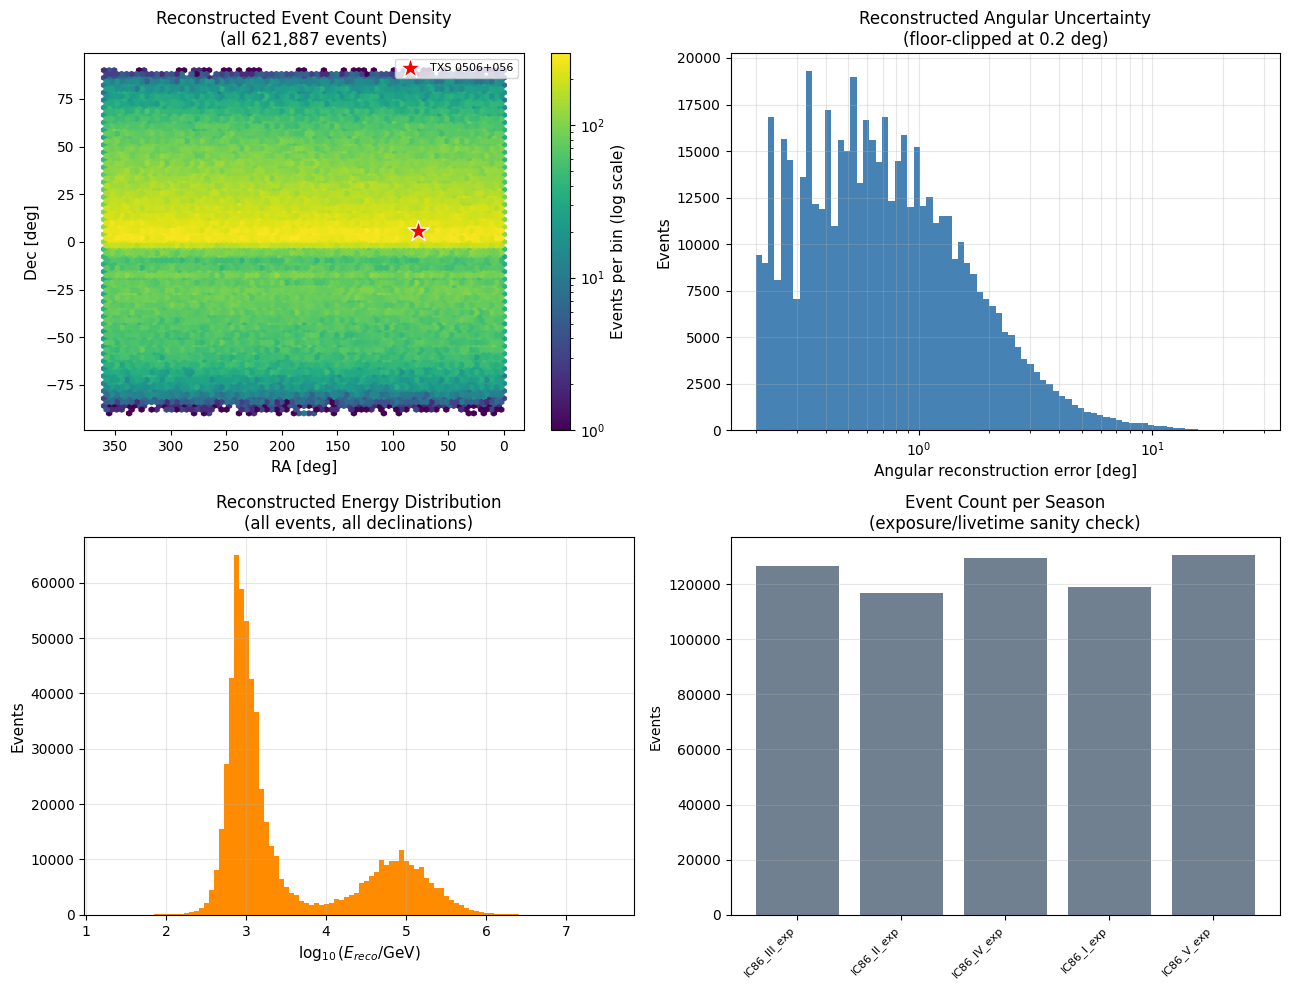

In [38]:
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
 
EPS = 1e-8  # small floor to keep LogNorm happy with exact zeros
 
 
 
# ============================================================
# SECTION A -- Observable: `events` (real reconstructed neutrino data)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
 
# A1. Sky density of all events, source position marked
ax = axes[0, 0]
hb = ax.hexbin(events["RA[deg]"], events["Dec[deg]"], gridsize=80, cmap="viridis", mincnt=1, norm=mcolors.LogNorm())
ax.scatter([SOURCE_RA_DEG], [SOURCE_DEC_DEG], marker="*", s=250, facecolor="red", edgecolor="white", linewidth=1, zorder=5, label=SOURCE_NAME)
ax.invert_xaxis()
ax.set_xlabel("RA [deg]", fontsize = 11)
ax.set_ylabel("Dec [deg]", fontsize = 11)
ax.set_title(f"Reconstructed Event Count Density\n(all {N_total:,} events)")
cb = plt.colorbar(hb, ax=ax)
cb.set_label("Events per bin (log scale)", fontsize = 11)
ax.legend(loc="upper right", fontsize=8)
 
# A2. Angular reconstruction error distribution
ax = axes[0, 1]
ang_err = events["AngErr[deg]"].values
ax.hist(ang_err, bins=np.logspace(np.log10(0.2), np.log10(ang_err.max()), 80),
        color="steelblue", edgecolor="none")
ax.set_xscale("log")
ax.set_xlabel("Angular reconstruction error [deg]", fontsize = 11)
ax.set_ylabel("Events", fontsize = 11)
ax.set_title("Reconstructed Angular Uncertainty\n(floor-clipped at 0.2 deg)")
ax.grid(alpha=0.3, which="both")
 
# A3. Reconstructed energy distribution
ax = axes[1, 0]
ax.hist(events["log10(E/GeV)"], bins=100, color="darkorange", edgecolor="none")
ax.set_xlabel(r"$\log_{10}(E_{reco}/\mathrm{GeV})$", fontsize = 11)
ax.set_ylabel("Events", fontsize = 11)
ax.set_title("Reconstructed Energy Distribution\n(all events, all declinations)")
ax.grid(alpha=0.3)
 
# A4. Events per season -- exposure/livetime sanity check
ax = axes[1, 1]
season_counts = events["season"].value_counts().sort_index()
ax.bar(range(len(season_counts)), season_counts.values, color="slategray")
ax.set_xticks(range(len(season_counts)))
ax.set_xticklabels(season_counts.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Events")
ax.set_title("Event Count per Season\n(exposure/livetime sanity check)")
ax.grid(alpha=0.3, axis="y")
 
plt.tight_layout()
plt.savefig("icecube_v6_extra_A_events_overview.png", dpi=120)
plt.show()
 

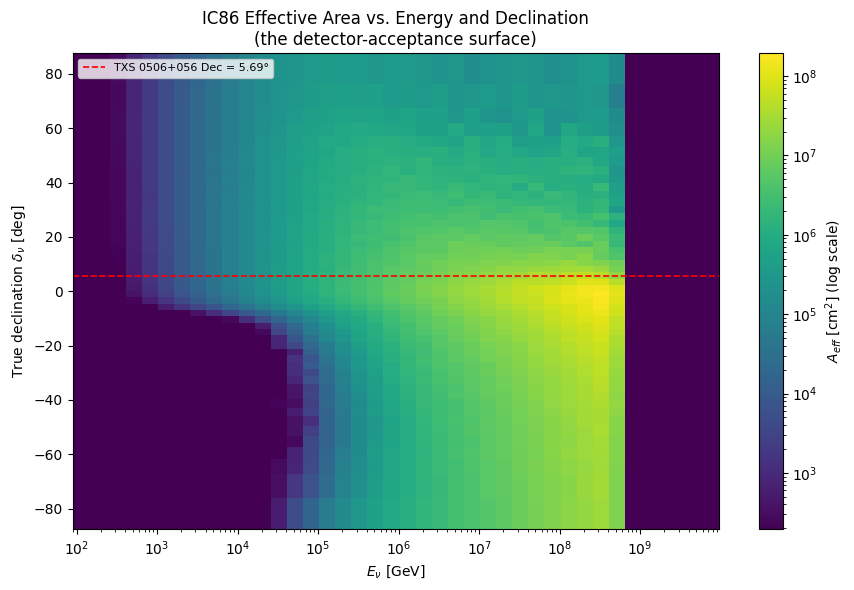

In [39]:

# ============================================================
# SECTION B -- Observable: `aeff` (effective area IRF)
# 2D map over energy AND declination, not just per-band lines --
# this is the full detector-acceptance surface the analysis draws on.
# ============================================================
aeff_plot = aeff.copy()
aeff_plot["E_nu_center"] = np.sqrt(10 ** aeff_plot["log10(E_nu/GeV)_min"] *
                                    10 ** aeff_plot["log10(E_nu/GeV)_max"])
aeff_plot["Dec_center"] = 0.5 * (aeff_plot["Dec_nu_min[deg]"] + aeff_plot["Dec_nu_max[deg]"])
 
Zdf = aeff_plot.pivot_table(index="Dec_center", columns="E_nu_center",
                             values="A_Eff[cm^2]").fillna(0.0)
Dec_bins_aeff = Zdf.index.values
E_bins_aeff = Zdf.columns.values
Z = Zdf.values + EPS
 
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.pcolormesh(E_bins_aeff, Dec_bins_aeff, Z, cmap="viridis",
                    norm=mcolors.LogNorm(vmin=max(Z.max() * 1e-6, EPS), vmax=Z.max()),
                    shading="auto")
ax.set_xscale("log")
ax.axhline(SOURCE_DEC_DEG, color="red", linestyle="--", linewidth=1.2,
           label=f"{SOURCE_NAME} Dec = {SOURCE_DEC_DEG:.2f}°")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"True declination $\delta_\nu$ [deg]")
ax.set_title("IC86 Effective Area vs. Energy and Declination\n"
             "(the detector-acceptance surface)")
cb = plt.colorbar(im, ax=ax)
cb.set_label(r"$A_{eff}$ [cm$^2$] (log scale)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("icecube_v6_extra_B_aeff_heatmap.png", dpi=120)
plt.show()
 

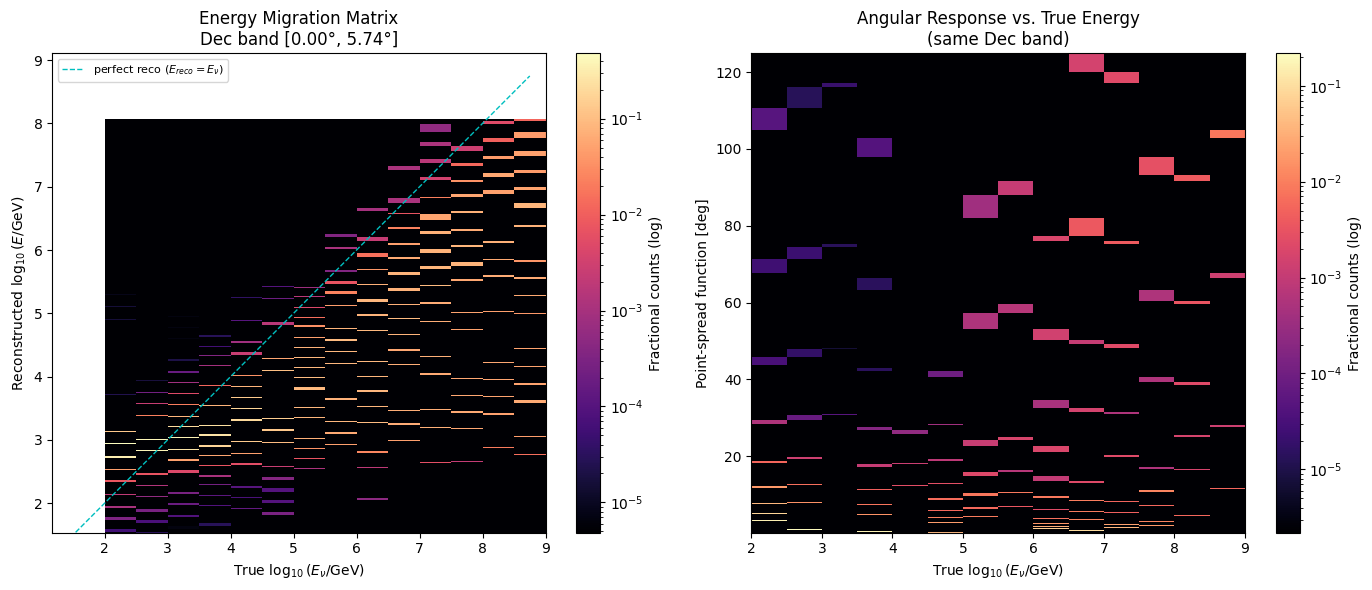

In [25]:

 
# ============================================================
# SECTION C -- Observable: `smearing` (true -> reco response matrix)
# Restricted to smearing_local (the source's own Dec band), since
# that's the slice the whole analysis actually uses.
# ============================================================
sm = smearing_local.copy()
sm["E_nu_center"] = 0.5 * (sm["log10(E_nu/GeV)_min"] + sm["log10(E_nu/GeV)_max"])
sm["E_reco_center"] = 0.5 * (sm["log10(E/GeV)_min"] + sm["log10(E/GeV)_max"])
sm["PSF_center"] = 0.5 * (sm["PSF_min[deg]"] + sm["PSF_max[deg]"])
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# C1. Energy migration matrix: true E_nu -> reconstructed E
ax = axes[0]
mig = sm.pivot_table(index="E_reco_center", columns="E_nu_center",
                      values="Fractional_Counts", aggfunc="sum").fillna(0.0)
mig_vals = mig.values + EPS
im = ax.pcolormesh(mig.columns.values, mig.index.values, mig_vals, cmap="magma",
                    norm=mcolors.LogNorm(vmin=max(mig_vals.max() * 1e-5, EPS), vmax=mig_vals.max()),
                    shading="auto")
lims = [min(mig.columns.min(), mig.index.min()), max(mig.columns.max(), mig.index.max())]
ax.plot(lims, lims, "c--", linewidth=1, label="perfect reco ($E_{reco}=E_\\nu$)")
ax.set_xlabel(r"True $\log_{10}(E_\nu/\mathrm{GeV})$")
ax.set_ylabel(r"Reconstructed $\log_{10}(E/\mathrm{GeV})$")
ax.set_title(f"Energy Migration Matrix\nDec band [{src_dec_min_smear:.2f}°, {src_dec_max_smear:.2f}°]")
cb = plt.colorbar(im, ax=ax)
cb.set_label("Fractional counts (log)")
ax.legend(loc="upper left", fontsize=8)
 
# C2. Angular response (PSF) vs true energy, same Dec band
ax = axes[1]
psf_mig = sm.pivot_table(index="PSF_center", columns="E_nu_center",
                          values="Fractional_Counts", aggfunc="sum").fillna(0.0)
psf_vals = psf_mig.values + EPS
im2 = ax.pcolormesh(psf_mig.columns.values, psf_mig.index.values, psf_vals, cmap="magma",
                     norm=mcolors.LogNorm(vmin=max(psf_vals.max() * 1e-5, EPS), vmax=psf_vals.max()),
                     shading="auto")
ax.set_xlabel(r"True $\log_{10}(E_\nu/\mathrm{GeV})$")
ax.set_ylabel("Point-spread function [deg]")
ax.set_title("Angular Response vs. True Energy\n(same Dec band)")
cb = plt.colorbar(im2, ax=ax)
cb.set_label("Fractional counts (log)")
 
plt.tight_layout()
plt.savefig("icecube_v6_extra_C_smearing_matrix.png", dpi=120)
plt.show()
 
 

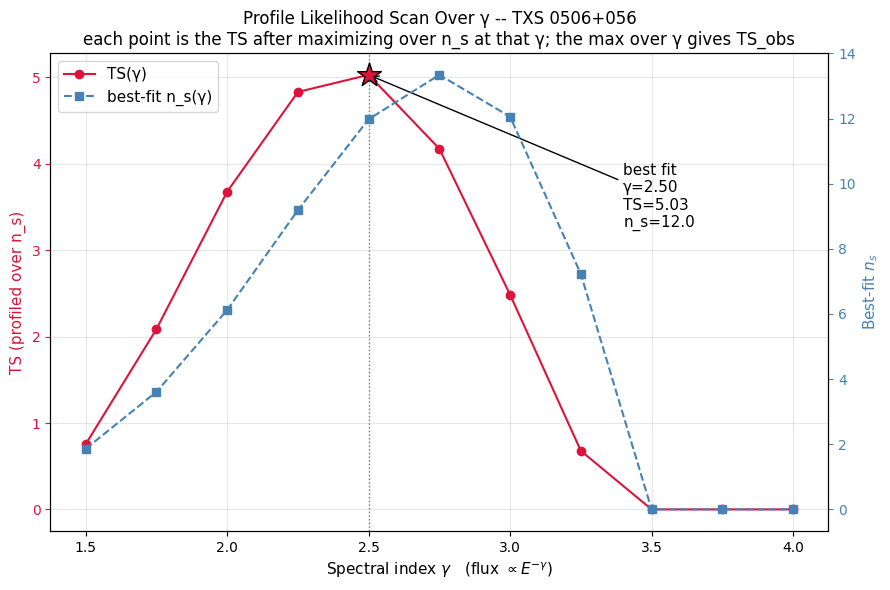

In [34]:
 
 
# ============================================================
# SECTION D -- Profile likelihood scan: TS(gamma) and n_s(gamma)
# together, at the real source position. Uses ts_vs_gamma /
# ns_vs_gamma computed once during the original gamma scan.
# ============================================================
fig, ax1 = plt.subplots(figsize=(9, 6))
ax2 = ax1.twinx()
 
l1, = ax1.plot(GAMMA_GRID, ts_vs_gamma, "o-", color="crimson", label="TS(γ)")
l2, = ax2.plot(GAMMA_GRID, ns_vs_gamma, "s--", color="steelblue", label="best-fit n_s(γ)")
 
ax1.axvline(gamma_obs, color="gray", linestyle=":", linewidth=1)
ax1.scatter([gamma_obs], [TS_obs], marker="*", s=320, color="crimson",
            edgecolor="black", zorder=5)
ax1.annotate(f"best fit\nγ={gamma_obs:.2f}\nTS={TS_obs:.2f}\nn_s={n_s_obs:.1f}",
             xy=(gamma_obs, TS_obs),
             xytext=(gamma_obs + 0.9, TS_obs * 0.65),
             fontsize=11, arrowprops=dict(arrowstyle="->", color="black"))
 
ax1.set_xlabel(r"Spectral index $\gamma$   (flux $\propto E^{-\gamma}$)", fontsize=11)
ax1.set_ylabel("TS (profiled over n_s)", color="crimson", fontsize=11)
ax2.set_ylabel(r"Best-fit $n_s$", color="steelblue", fontsize = 11)
ax1.tick_params(axis="y", colors="crimson")
ax2.tick_params(axis="y", colors="steelblue")
ax1.set_title(f"Profile Likelihood Scan Over γ -- {SOURCE_NAME}\n"
              "each point is the TS after maximizing over n_s at that γ; "
              "the max over γ gives TS_obs")
ax1.grid(alpha=0.3)
ax1.legend(handles=[l1, l2], loc="upper left", fontsize=11)
plt.tight_layout()
plt.savefig("icecube_v6_extra_D_TS_ns_vs_gamma.png", dpi=120)
plt.show()
 

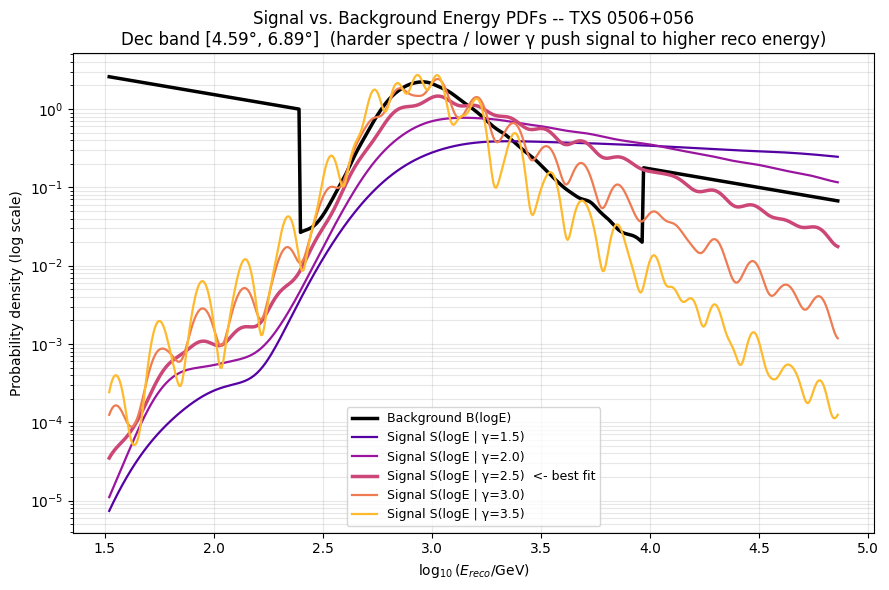

In [27]:

# ============================================================
# SECTION E -- Signal energy PDF S(logE | gamma) for several gammas,
# overlaid on the background energy PDF B(logE). Rebuilds
# S_energy via build_signal_energy_kde(), which is cheap (a single
# weighted KDE over the smearing table) -- no trials involved.
# ============================================================
gammas_to_show = [g for g in [1.5, 2.0, 2.5, 3.0, 3.5] if g in set(np.round(GAMMA_GRID, 2))]
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(gammas_to_show)))
 
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(kde_grid, B_energy(kde_grid), color="black", linewidth=2.5,
        label="Background B(logE)")
 
for gamma, c in zip(gammas_to_show, colors):
    S_fn = build_signal_energy_kde(gamma)
    lbl = f"Signal S(logE | γ={gamma})" + ("  <- best fit" if np.isclose(gamma, gamma_obs) else "")
    lw = 2.5 if np.isclose(gamma, gamma_obs) else 1.6
    ax.plot(kde_grid, S_fn(kde_grid), color=c, linewidth=lw, label=lbl)
 
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10}(E_{reco}/\mathrm{GeV})$")
ax.set_ylabel("Probability density (log scale)")
ax.set_title(f"Signal vs. Background Energy PDFs -- {SOURCE_NAME}\n"
             f"Dec band [{src_dec_min:.2f}°, {src_dec_max:.2f}°]  "
             "(harder spectra / lower γ push signal to higher reco energy)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("icecube_v6_extra_E_signal_vs_background_energy_pdf.png", dpi=120)
plt.show()
 

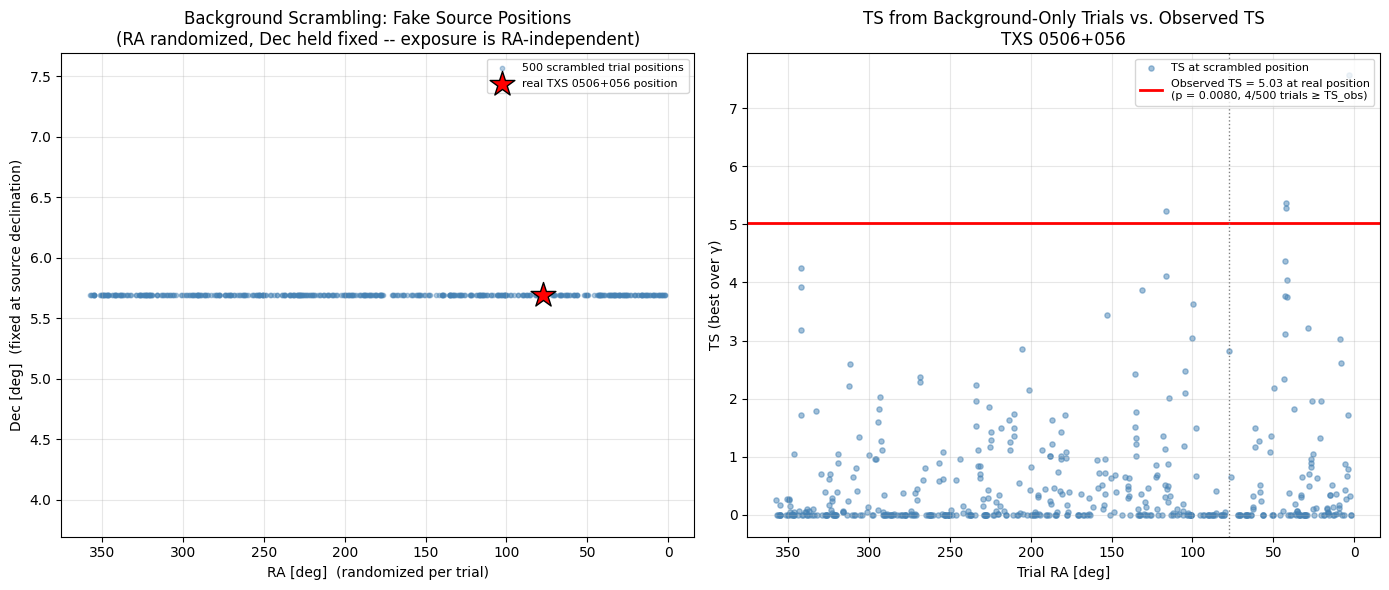


Done. Saved: icecube_v6_extra_A through icecube_v6_extra_F (.png).


In [28]:

# ============================================================
# SECTION F -- Illustrating the background-scrambling procedure.
# Uses trial_ras and TS_trials already computed in the 500-trial
# loop -- does NOT rerun any trials.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# F1. Where the "fake sources" were placed: same Dec, random RA
ax = axes[0]
trial_ra_deg = np.degrees(trial_ras)
ax.scatter(trial_ra_deg, np.full(N_TRIALS, SOURCE_DEC_DEG), s=10, alpha=0.4,
           color="steelblue", label=f"{N_TRIALS} scrambled trial positions")
ax.scatter([SOURCE_RA_DEG], [SOURCE_DEC_DEG], marker="*", s=350, color="red",
           edgecolor="black", zorder=5, label=f"real {SOURCE_NAME} position")
ax.set_xlabel("RA [deg]  (randomized per trial)")
ax.set_ylabel("Dec [deg]  (fixed at source declination)")
ax.set_ylim(SOURCE_DEC_DEG - 2, SOURCE_DEC_DEG + 2)
ax.invert_xaxis()
ax.set_title("Background Scrambling: Fake Source Positions\n"
             "(RA randomized, Dec held fixed -- exposure is RA-independent)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
 
# F2. TS achieved at each scrambled position vs. the real observed TS
ax = axes[1]
n_exceeding = int((TS_trials >= TS_obs).sum())
ax.scatter(trial_ra_deg, TS_trials, s=14, alpha=0.5, color="steelblue",
           label="TS at scrambled position")
ax.axhline(TS_obs, color="red", linewidth=2,
           label=f"Observed TS = {TS_obs:.2f} at real position\n"
                 f"(p = {p_value:.4f}, {n_exceeding}/{N_TRIALS} trials ≥ TS_obs)")
ax.axvline(SOURCE_RA_DEG, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Trial RA [deg]")
ax.set_ylabel("TS (best over γ)")
ax.invert_xaxis()
ax.set_title(f"TS from Background-Only Trials vs. Observed TS\n{SOURCE_NAME}")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("icecube_v6_extra_F_background_scrambling_illustration.png", dpi=120)
plt.show()
 
print("\nDone. Saved: icecube_v6_extra_A through icecube_v6_extra_F (.png).")

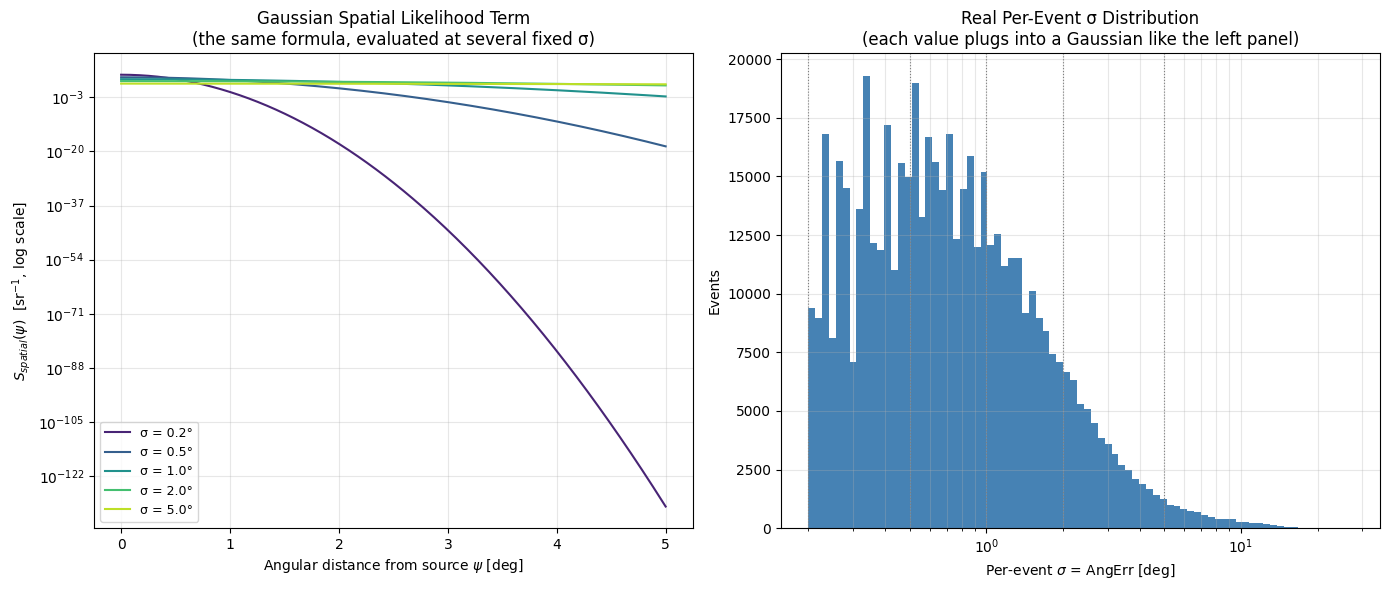

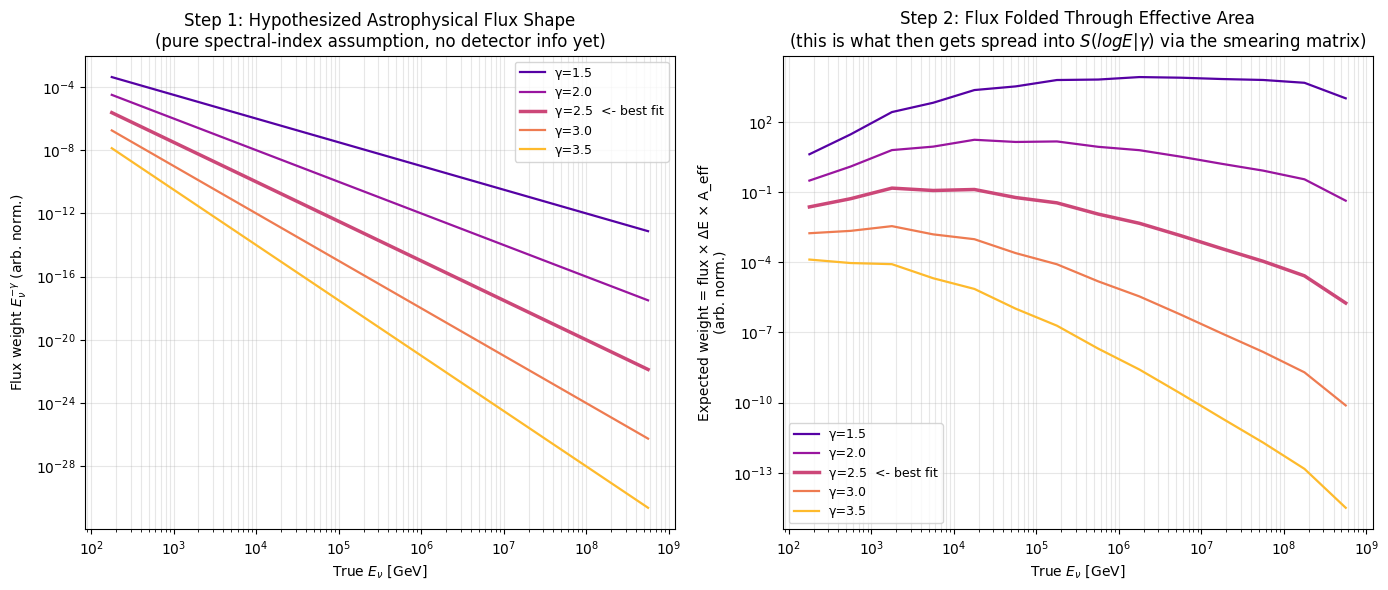

Saved: icecube_v6_extra_G_spatial_gaussian_term.png, icecube_v6_extra_H_gamma_flux_aeff_weighting.png


In [40]:
# ============================================================
# IceCube Point-Source Stage 2 (v6) -- LIKELIHOOD STRUCTURE VISUALS
#
# Visualizes the two components that get multiplied together to form
# the per-event likelihood ratio S/B:
#   G. The Gaussian spatial term S_spatial(psi | sigma) on its own,
#      as a pure function -- shows what "per-event angular
#      uncertainty" actually does to the likelihood shape.
#   H. The gamma-weighted astrophysical-flux x effective-area term,
#      BEFORE it gets folded through the smearing matrix and smoothed
#      into S_energy(logE|gamma) -- shows exactly what "weighted by
#      gamma" means, isolated from the KDE smoothing step.
#
# Paste at the end of your v6 pipeline (same kernel session).
# Assumes: S_spatial, B_spatial, merged, sigma_all, GAMMA_GRID,
# gamma_obs, SOURCE_NAME already exist in memory. No recomputation.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

gammas_to_show = [g for g in [1.5, 2.0, 2.5, 3.0, 3.5] if g in set(np.round(GAMMA_GRID, 2))]
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(gammas_to_show)))


# ============================================================
# SECTION G -- The Gaussian spatial term, S_spatial(psi | sigma),
# shown as a pure function of angular distance, for several
# representative per-event angular uncertainties (sigma).
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# G1. The functional shape itself -- narrower sigma = tighter, taller
# Gaussian; this IS the "per-event angular uncertainty" in the claim.
ax = axes[0]
psi_grid_deg = np.linspace(0, 5, 300)
psi_grid_rad = np.radians(psi_grid_deg)
sigma_examples_deg = [0.2, 0.5, 1.0, 2.0, 5.0]  # 0.2 deg = the AngErr floor in your pipeline

for sig_deg, c in zip(sigma_examples_deg, plt.cm.viridis(np.linspace(0.1, 0.9, len(sigma_examples_deg)))):
    sig_rad = np.radians(sig_deg)
    S_vals = (1.0 / (2 * np.pi * sig_rad ** 2)) * np.exp(-psi_grid_rad ** 2 / (2 * sig_rad ** 2))
    ax.plot(psi_grid_deg, S_vals, color=c, label=f"σ = {sig_deg}°")

ax.set_yscale("log")
ax.set_xlabel(r"Angular distance from source $\psi$ [deg]")
ax.set_ylabel(r"$S_{spatial}(\psi)$  [sr$^{-1}$, log scale]")
ax.set_title("Gaussian Spatial Likelihood Term\n(the same formula, evaluated at several fixed σ)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# G2. What sigma actually looks like across your real events -- this
# is the distribution S_spatial's width is drawn from, event by event.
ax = axes[1]
ang_err_deg = np.degrees(sigma_all)
ax.hist(ang_err_deg, bins=np.logspace(np.log10(0.2), np.log10(ang_err_deg.max()), 80),
        color="steelblue", edgecolor="none")
for sig_deg in sigma_examples_deg:
    ax.axvline(sig_deg, color="gray", linestyle=":", linewidth=0.8)
ax.set_xscale("log")
ax.set_xlabel(r"Per-event $\sigma$ = AngErr [deg]")
ax.set_ylabel("Events")
ax.set_title("Real Per-Event σ Distribution\n(each value plugs into a Gaussian like the left panel)")
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("icecube_v6_extra_G_spatial_gaussian_term.png", dpi=120)
plt.show()


# ============================================================
# SECTION H -- The gamma-weighted flux x effective-area term,
# BEFORE the smearing-matrix fold and KDE smoothing.
# This isolates exactly what "weighted by a hypothesized
# astrophysical spectral index gamma" means in build_signal_energy_kde.
# ============================================================
# One row per unique true-energy bin (A_Eff and dE_nu don't depend on
# the reco-energy sub-binning, so this de-duplicates cleanly).
unique_true = (merged.drop_duplicates(subset="E_nu_center")
                      [["E_nu_center", "dE_nu", "A_Eff[cm^2]"]]
                      .sort_values("E_nu_center"))
E_nu = unique_true["E_nu_center"].values
dE_nu = unique_true["dE_nu"].values
A_eff_true = unique_true["A_Eff[cm^2]"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# H1. The raw flux weighting E_nu^-gamma alone (astrophysics assumption only)
ax = axes[0]
for gamma, c in zip(gammas_to_show, colors):
    flux_weight = E_nu ** (-gamma)
    lbl = f"γ={gamma}" + ("  <- best fit" if np.isclose(gamma, gamma_obs) else "")
    lw = 2.5 if np.isclose(gamma, gamma_obs) else 1.6
    ax.plot(E_nu, flux_weight, color=c, linewidth=lw, label=lbl)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"True $E_\nu$ [GeV]")
ax.set_ylabel(r"Flux weight $E_\nu^{-\gamma}$ (arb. norm.)")
ax.set_title("Step 1: Hypothesized Astrophysical Flux Shape\n(pure spectral-index assumption, no detector info yet)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# H2. After multiplying in dE_nu and A_Eff (detector acceptance folded in)
# -- this is "nu_weight" in the code, i.e. flux x effective area, still
# in TRUE energy, still before the smearing matrix spreads it into
# reconstructed energy via Fractional_Counts + KDE.
ax = axes[1]
for gamma, c in zip(gammas_to_show, colors):
    flux_weight = E_nu ** (-gamma)
    nu_weight = flux_weight * dE_nu * A_eff_true
    lbl = f"γ={gamma}" + ("  <- best fit" if np.isclose(gamma, gamma_obs) else "")
    lw = 2.5 if np.isclose(gamma, gamma_obs) else 1.6
    ax.plot(E_nu, nu_weight, color=c, linewidth=lw, label=lbl)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"True $E_\nu$ [GeV]")
ax.set_ylabel("Expected weight = flux × ΔE × A_eff\n(arb. norm.)")
ax.set_title("Step 2: Flux Folded Through Effective Area\n(this is what then gets spread into $S(logE|\\gamma)$ via the smearing matrix)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("icecube_v6_extra_H_gamma_flux_aeff_weighting.png", dpi=120)
plt.show()

print("Saved: icecube_v6_extra_G_spatial_gaussian_term.png, "
      "icecube_v6_extra_H_gamma_flux_aeff_weighting.png")